In [171]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [172]:
#Import the csv file
df=pd.read_csv('loan_2014_18.csv')
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,120122535,12000.0,12000.0,12000.0,36 months,7.97%,375.88,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,119374887,32000.0,32000.0,32000.0,36 months,11.99%,1062.71,B,B5,...,Apr-2020,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N
2,2,119321612,40000.0,40000.0,40000.0,60 months,15.05%,952.65,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,3,120122034,16000.0,16000.0,16000.0,36 months,7.97%,501.17,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,4,118659541,33000.0,33000.0,33000.0,36 months,7.21%,1022.12,A,A3,...,Feb-2020,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N


In [173]:
df.shape

(2029952, 142)

In [174]:
df.columns

Index(['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_length', 'hardship_dpd', 'hardship_loan_status',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag'],
      dtype='object', length=142)

## Dependent variable set up

In [175]:
#Look at the unique values
df["loan_status"].unique()

array(['Fully Paid', 'Current', 'Late (31-120 days)', 'Charged Off',
       'In Grace Period', 'Late (16-30 days)', 'Default'], dtype=object)

In [ ]:
#Create the loan mapping for the dependent variable
loan_mapping_label = {
"Fully Paid":1, #Loan was repaid in full
"Current":1, #borrower is currenntly making payments
"Late (31-120 days)":0, #Payment is overdue
"Charged Off":0, #lender considers the loan unlikely to be collected
"In Grace Period": 1, #Slightly overdue payment but still within allowed extra time
"Late (16-30 days)":0, #Payment is overdue
"Default":0 #loan is officially failed to be repaid
}
#The dependent variable represents whether the loan is in a broadly performing state versus a distressed/non-performing state.

In [177]:
#Create the dependent variable with the mapping
df["y"] = df["loan_status"].map(loan_mapping_label)
df.drop("loan_status",axis =1,inplace=True)

In [178]:
#look at the value counts of the created dependent variables
df["y"].value_counts()

y
1    1704881
0     325071
Name: count, dtype: int64

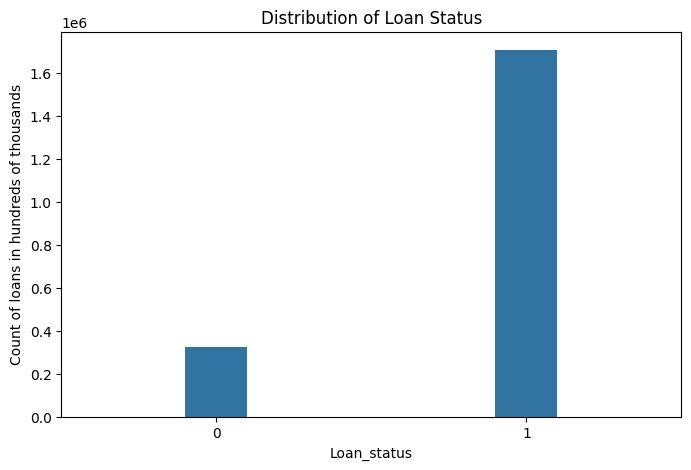

In [179]:
plt.figure(figsize=(8,5)) #Change the figure size
sns.countplot(data=df,x="y",width=0.2)
plt.title("Distribution of Loan Status")
plt.xlabel("Loan_status")
plt.ylabel("Count of loans in hundreds of thousands")
plt.show()

## -----------

## Adress missing Values
We will be removing the values that are 51% or more missing since we have many columns and this is a way we can get to lower the number of available good columns

In [180]:
def Missing_data_report(df:pd.DataFrame,threshold:float):
    """
    Constructs a Dataframe that contains the columns number of null data values,
    their respective percentage missigness 
    
    Parameters:
    df(pd.Dataframe):Dataframe to analyze
    Threshold(float):the threshold or tolerance of percentage of columns that we do
    do want to get rid of eg:51 in this case brings the columns with >= % of null values in the columns

    returns:
    pd.DataFrame:The pandas dataframe of the report
    """
    #Count missing values
    missing = df.isna().sum()

    #Create dataframe
    missing_df = pd.DataFrame({
        "Column": missing.index,
        "m_cnt": missing.values
    })

    #Keep the columns with missing values
    missing_df = missing_df[missing_df["m_cnt"]>0]

    #calculate missing percentage
    missing_df["Missing_pcn"] = round(missing_df["m_cnt"] / df.shape[0] *100,2)
    
    #apply threshold filer
    missing_df=missing_df[missing_df["Missing_pcn"]> threshold]

    missing_df = missing_df.sort_values("Missing_pcn",ascending=False).reset_index(drop=True)
    return missing_df



In [181]:
#Apply the missing data report in the df
missing_report_df = Missing_data_report(df,threshold=51)
missing_report_df.head(3)

,Column,m_cnt,Missing_pcn
0,hardship_loan_status,1956776,96.40
1,hardship_status,1956677,96.39
2,hardship_reason,1956678,96.39


In [182]:
#We drop the columns with 51 % or above missing percent
columns_to_drop = missing_report_df["Column"].values
df.drop(columns=columns_to_drop, errors ="ignore", inplace=True)

In [183]:
#We can see we have trimmed about 33 columns
df.shape

(2029952, 108)

## --------------------

## Categorical columns

In [184]:
#Look at what we have currently 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029952 entries, 0 to 2029951
Columns: 108 entries, Unnamed: 0 to y
dtypes: float64(82), int64(3), object(23)
memory usage: 1.6+ GB


In [185]:
# Remove leading/trailing whitespaces from objects column names
df = df.apply(lambda col: col.str.strip() if col.dtypes == 'object' else col, axis=0)
#Strip again for safe measure
df.columns= df.columns.str.strip()

In [186]:
def sort_unique(df:pd.DataFrame, show_columns = False,descending_values:bool = False, plot:bool = False):
    #Functions that extracts the number of unique values and compare it with the number of rows
    Cat_columns = df.select_dtypes(include=["object","category"]).columns
    unique_dict = {col: len(df[col].unique()) for col in Cat_columns}
    unique_list = list(unique_dict.values())
    count_dataframe = pd.DataFrame(list(unique_dict.items()), columns=["Columns","num_unique"])
    count_dataframe = count_dataframe.sort_values(by="num_unique", ascending=descending_values)
    count_dataframe["perc"] = count_dataframe["num_unique"] / df.shape[0] * 100
    if show_columns:
        return count_dataframe, Cat_columns
    if plot:
        plt.figure(figsize=(30,5)) #Change the figure size
        sns.barplot(data=count_dataframe,x=Cat_columns,y = unique_list,width=0.2)
        plt.title("Distribution of number of unique values")
        plt.xlabel("columns")
        plt.ylabel("Count of unique values")
        plt.show()
    return count_dataframe


In [187]:
sort_unique(df).reset_index(drop=True).head(3)

,Columns,num_unique,perc
0,url,2029952,100.000000
1,emp_title,359722,17.720715
2,title,1998,0.098426


Here we notice that pymnt_plan, has only 1 unique value thus it is not very informative, url has all distinct so it is better to get rid of it since it would provide no statistical value. emp_title and title can produce too much high cardinality thus we will remove those as well. We also notice that revol_util, int_rate have high cardinality, but talking a closer look we can see that they all end with '%' and denoted as a string when they could be numeric.


We can also see that earliest_cr_line,last_pymnt_d, last_credit_pull_d, and issue_d are all seem to be date values and must be addressed accordingly

In [188]:
df.drop(["url","emp_title","title", "pymnt_plan", "zip_code"], axis=1, inplace=True)

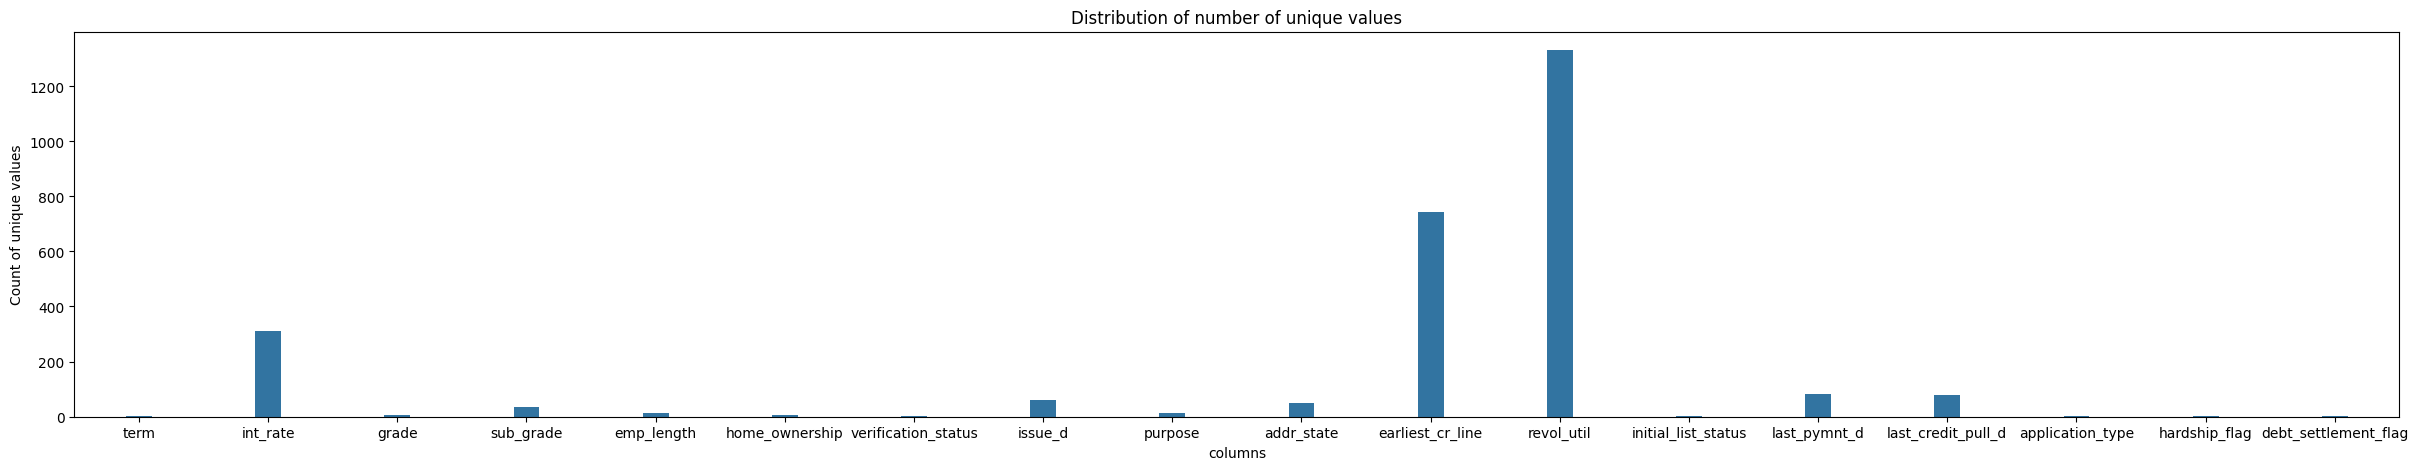

,Columns,num_unique,perc
0,term,2,0.000099
1,application_type,2,0.000099
2,initial_list_status,2,0.000099
3,debt_settlement_flag,2,0.000099
4,hardship_flag,3,0.000148
5,verification_status,3,0.000148
6,home_ownership,5,0.000246
7,grade,7,0.000345
8,emp_length,12,0.000591
9,purpose,14,0.000690


In [189]:
sort_unique(df, descending_values=True, plot=True).reset_index(drop=True)

## -----------------

## Date Type columns

In [190]:
#For self reference: %Y = year(4 digit), %y = year(2digit), %m = month(01-12), %d = day of the month (01-31), %b abbreviated month name(jan,feb,mar...)

df["issue_d"] = pd.to_datetime(df["issue_d"], format = "%Y-%m-%d")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format = "%b-%Y")
df["last_credit_pull_d"] = pd.to_datetime(df["last_credit_pull_d"], format = "%b-%Y")
df["last_pymnt_d"] = pd.to_datetime(df["last_pymnt_d"], format = "%b-%Y")

In [191]:
date_cols = df.select_dtypes(include="datetime64")
date_cols.head(3)

,issue_d,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,2017-09-01,1996-06-01,2020-05-01,2020-05-01
1,2017-09-01,2005-09-01,2020-05-01,2020-05-01
2,2017-09-01,2002-04-01,2020-05-01,2020-05-01


In [192]:
#Inspect missingness of the columns
date_cols.isna().sum()

issue_d                  0
earliest_cr_line         0
last_pymnt_d          2190
last_credit_pull_d      58
dtype: int64

In [193]:
#Compute the loan days since been issued
df["Customer_history"] = (df["issue_d"] - df["earliest_cr_line"]).dt.days

#Date components
df["issue_year"] = df["issue_d"].dt.year.astype("category")
df["issue_month"] = df["issue_d"].dt.month.astype("category")


In [194]:
#Drop the non used date variables(The ones not created)
df.drop(date_cols, axis=1,inplace=True)

## ----------------------

In [195]:
#Take a look into the numerical columns
df.select_dtypes(include="number").head(3)

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,y,Customer_history
0,0,120122535,12000.0,12000.0,12000.0,375.88,42000.0,27.74,0.0,715.0,...,100.0,0.0,1.0,0.0,57180.0,30502.0,15500.0,26180.0,1,7762
1,1,119374887,32000.0,32000.0,32000.0,1062.71,155000.0,12.35,2.0,715.0,...,94.9,0.0,0.0,0.0,527034.0,63891.0,124200.0,20034.0,1,4383
2,2,119321612,40000.0,40000.0,40000.0,952.65,120000.0,31.11,0.0,765.0,...,100.0,0.0,0.0,0.0,367745.0,154261.0,64600.0,168145.0,1,5632


In [196]:
#Take a look into the columns left for categorical
df.select_dtypes(include=["object","category"]).head(3)

,term,int_rate,grade,sub_grade,emp_length,home_ownership,verification_status,purpose,addr_state,revol_util,initial_list_status,application_type,hardship_flag,debt_settlement_flag,issue_year,issue_month
0,36 months,7.97%,A,A5,10+ years,OWN,Source Verified,debt_consolidation,CA,37%,w,Individual,N,N,2017,9
1,36 months,11.99%,B,B5,10+ years,MORTGAGE,Source Verified,credit_card,NJ,34.1%,w,Individual,Y,N,2017,9
2,60 months,15.05%,C,C4,9 years,MORTGAGE,Verified,debt_consolidation,TX,20.7%,w,Individual,N,N,2017,9


## Re-visit Categorical

In [197]:
def categorical_analysis(df:pd.DataFrame, show_counts:bool = False,number_to_show:int =-1):
    Cat_columns = df.select_dtypes(include=["object","category"]).columns
    for col in Cat_columns[:number_to_show]:
        value_counts = list()
        unique_values = df[col].unique()
        for val in unique_values:
            value_counts.append(len(df[df[col]==val]))

        plt.figure(figsize=(10,5)) #Change the figure size
        sns.barplot(x=unique_values, y=value_counts, width = 0.3)
        plt.title(f"Distribution of number of unique values for {col} column")
        plt.xlabel(col)
        plt.ylabel("Count of unique values")
        plt.show()
        if show_counts:
            print(df[col].value_counts())

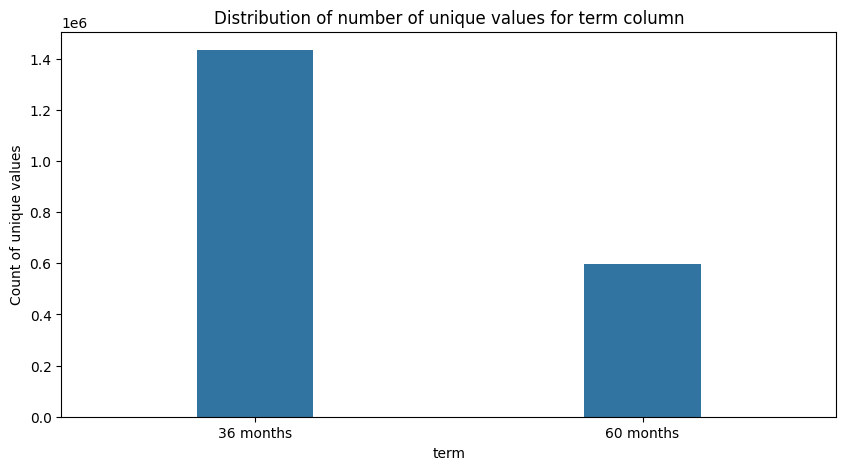

term
36 months    1434328
60 months     595624
Name: count, dtype: int64


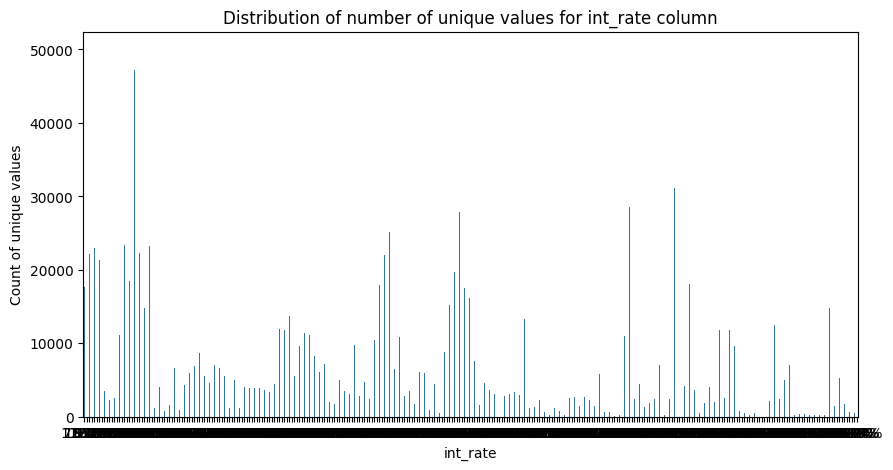

int_rate
11.99%    49942
5.32%     47171
13.99%    41725
10.99%    40010
11.49%    31169
          ...  
13.19%        1
17.50%        1
19.20%        1
16.90%        1
11.16%        1
Name: count, Length: 310, dtype: int64


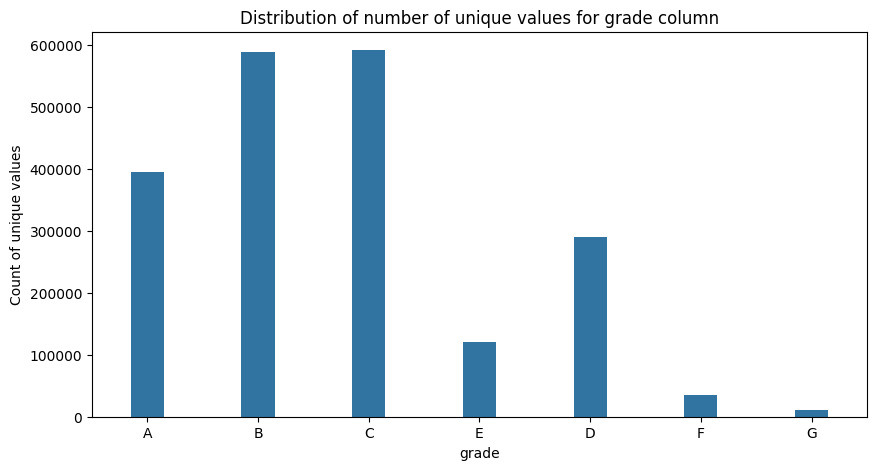

grade
C    591304
B    588545
A    394264
D    290516
E    120001
F     34791
G     10531
Name: count, dtype: int64


In [198]:
categorical_analysis(df, show_counts=True,number_to_show=3)

In [199]:
#We take a look into revol util and int rate
df["revol_util"]

0            37%
1          34.1%
2          20.7%
3          57.7%
4          16.1%
           ...  
2029947    24.9%
2029948    15.7%
2029949      47%
2029950    10.1%
2029951    72.6%
Name: revol_util, Length: 2029952, dtype: object

In [200]:
df["int_rate"]

0           7.97%
1          11.99%
2          15.05%
3           7.97%
4           7.21%
            ...  
2029947    23.99%
2029948     7.99%
2029949    16.99%
2029950    11.44%
2029951    25.49%
Name: int_rate, Length: 2029952, dtype: object

In [201]:
#We will strip away the "%" sign at the end and convet into a numerical value
df["int_rate"] = pd.to_numeric(df["int_rate"].str.strip("%"))
df["int_rate"]

0           7.97
1          11.99
2          15.05
3           7.97
4           7.21
           ...  
2029947    23.99
2029948     7.99
2029949    16.99
2029950    11.44
2029951    25.49
Name: int_rate, Length: 2029952, dtype: float64

In [202]:


#We do the same with revol util
df["revol_util"] = pd.to_numeric(df["revol_util"].str.strip("%"))
df["revol_util"]

0          37.0
1          34.1
2          20.7
3          57.7
4          16.1
           ... 
2029947    24.9
2029948    15.7
2029949    47.0
2029950    10.1
2029951    72.6
Name: revol_util, Length: 2029952, dtype: float64

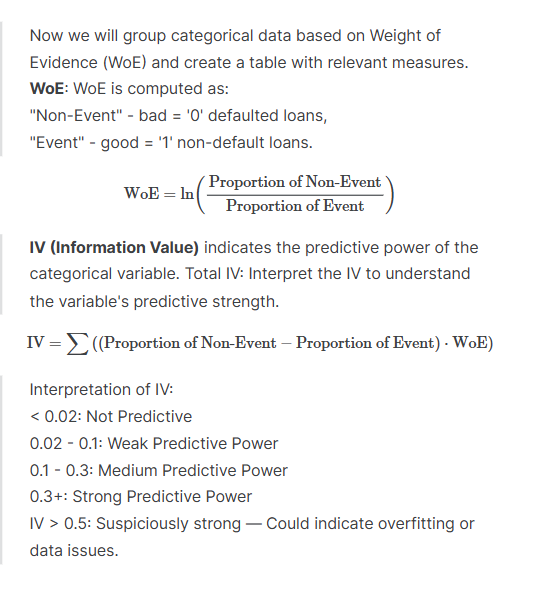

In [203]:


def WOE(df:pd.DataFrame):
    '''
    A function that gives us the WoE, and components to compute the IV of each categorical column
    '''
    Cat_columns = df.select_dtypes(include=["object","category"]).columns
    cols = [col for col in Cat_columns if df[col].nunique() <= 7 and col != "y"]
    col_list = []
    value_list = []
    woe = list()
    prop_events = []
    prop_non_events = []
    IV_components = []
    
    total_events = df["y"].sum()
    total_non_events = len(df) - total_events
    for col in cols:
        col_data = df[col].astype("object").fillna("Missing")
        unique_values = col_data.unique()
        for val in unique_values:
            #For each specific unique value in the categrocial column
            mask = col_data == val

            #number of events for the specific categroical column with specific value df[mask]
            row_count = df.loc[mask].shape[0]
            #the event occuring for the specific dependent variable value df[mask|y=1]
            event_count = df.loc[mask, "y"].sum()
            #The number of non event count
            non_event_count = row_count - event_count

            #proportion of event in the sample space of y=1
            prop_event = event_count / total_events
            #proportion of event in the sample space of y=0
            prop_non_event = non_event_count / total_non_events

            
            epsilon = 1e-6
            woe_val = np.log((prop_non_event + epsilon) /( prop_event + epsilon))

            IV_component = (prop_non_event-prop_event) * woe_val

            woe.append(woe_val)
            col_list.append(col)
            value_list.append(val)
            prop_events.append(prop_event)
            prop_non_events.append(prop_non_event)
            IV_components.append(IV_component)


    return pd.DataFrame(
        {
            "Column":col_list,
            "WoE" : woe,
            "value": value_list,
            "Prop_events":prop_events,
            "Prop_non_events":prop_non_events,
            "IV_component":IV_components

        }
    )


In [204]:
IV_df = WOE(df)
IV_df.columns

Index(['Column', 'WoE', 'value', 'Prop_events', 'Prop_non_events',
       'IV_component'],
      dtype='object')

In [205]:
IV_df.head()

,Column,WoE,value,Prop_events,Prop_non_events,IV_component
0,term,-0.200864,36 months,0.727791,0.595350,0.026603
1,term,0.396451,60 months,0.272209,0.404650,0.052506
2,grade,-1.292798,A,0.219754,0.060322,0.206114
3,grade,-0.421990,B,0.306847,0.201211,0.044577
4,grade,0.152949,C,0.283779,0.330679,0.007173


In [206]:
#Round the iv components
IV_df["IV_component"] = round(IV_df["IV_component"],4)

In [207]:
#Take a glimpse of the IV component to see if it rounded well
IV_df[["Column","value","IV_component"]].head()

,Column,value,IV_component
0,term,36 months,0.0266
1,term,60 months,0.0525
2,grade,A,0.2061
3,grade,B,0.0446
4,grade,C,0.0072


In [208]:
#Calculate the IV
IV_table = pd.DataFrame(IV_df.groupby("Column")["IV_component"].sum().reset_index().rename(columns={"IV_component":"IV"}))

In [209]:
IV_table.sort_values(by="IV", ascending=False).reset_index(drop=True)

,Column,IV
0,debt_settlement_flag,1.2498
1,grade,0.4461
2,hardship_flag,0.1083
3,term,0.0791
4,verification_status,0.0655
5,issue_year,0.0599
6,home_ownership,0.0287
7,initial_list_status,0.0100
8,application_type,0.0020


* We can see that Initial list satus and application type do not seem to have much precitive power as opposed to the others. On the other hand debt settlement flag seems to be having a really high IV value indicating possible problems in our modeling which may be needed to asses later down the line

In [210]:
#Drop IV column values that are  < 0.2
low_iv_cols = IV_table.loc[IV_table["IV"] <= 0.02,"Column"].to_list()
low_iv_cols

['application_type', 'initial_list_status']

In [211]:
df.drop(low_iv_cols,axis=1,inplace=True)

## -----------------------------------

## Numerical Columns

In [212]:
#extract the numerical columns of the df and quickly get a glimps into what we have
numerical_columns = df.select_dtypes(include="number", exclude=["category","object"]).drop('y', axis=1).columns

In [213]:
numerical_columns[:3]

Index(['Unnamed: 0', 'id', 'loan_amnt'], dtype='object')

In [214]:
df[numerical_columns].head(3)

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,Customer_history
0,0,120122535,12000.0,12000.0,12000.0,7.97,375.88,42000.0,27.74,0.0,...,3.0,100.0,0.0,1.0,0.0,57180.0,30502.0,15500.0,26180.0,7762
1,1,119374887,32000.0,32000.0,32000.0,11.99,1062.71,155000.0,12.35,2.0,...,5.0,94.9,0.0,0.0,0.0,527034.0,63891.0,124200.0,20034.0,4383
2,2,119321612,40000.0,40000.0,40000.0,15.05,952.65,120000.0,31.11,0.0,...,2.0,100.0,0.0,0.0,0.0,367745.0,154261.0,64600.0,168145.0,5632


In [215]:
#After noticing some numerical columns with small unique values like 2 or < 10 then we look at the columns with the < 10
for col in numerical_columns:
    if df[col].nunique() <= 10:
        print(col)
        print(df[col].nunique())
        print(df[col].unique())
        if df[col].nunique() == 1:
            print(col)

inq_last_6mths
7
[ 0.  1.  2.  4.  3.  5.  6. nan]
policy_code
1
[1.]
policy_code
acc_now_delinq
9
[ 0.  1.  2.  3.  7.  4.  5.  6. 14.]
num_tl_120dpd_2m
7
[ 0. nan  1.  2.  7.  3.  6.  4.]
num_tl_30dpd
5
[0. 1. 2. 3. 4.]


In [216]:
#I chose to transform the low cardinality numerical values into categorical values to use more appropriate techniques for its column shape
df["num_tl_120dpd_2m"] = df["num_tl_120dpd_2m"].astype("category")
df["inq_last_6mths"] = df["inq_last_6mths"].astype("category")
df["num_tl_30dpd"] = df["num_tl_30dpd"].astype("category")

In [217]:
#Clip to 3 values se we can have 0,1,2,3+ but we have to make it into numeric then into gategorical
df["acc_now_delinq"] = pd.to_numeric(df["acc_now_delinq"], errors="coerce")
df["acc_now_delinq"] = df["acc_now_delinq"].clip(upper=3)
df["acc_now_delinq"] = df["acc_now_delinq"].astype("category")

In [218]:
#Only has 1 value thus it's not informative
df.drop("policy_code",axis=1, inplace=True)

In [219]:
numerical_columns = df.select_dtypes(include="number", exclude=["category","object"]).drop('y', axis=1).columns

In [220]:
#Check if we dealt with all the low cardinality columns appropriately
for col in numerical_columns:
    if df[col].nunique() <= 10:
        print(col)
        print(df[col].nunique())
        print(df[col].unique())
        if df[col].nunique() == 1:
            print(col)

In [221]:
#Drop the id columns as they are just extra index columns
df.drop(['Unnamed: 0', 'id'], axis=1,inplace=True)

In [222]:
#Re-calculate the numerical columns again
numerical_columns = df.select_dtypes(include="number", exclude=["category","object"]).drop('y', axis=1).columns

In [223]:
#Look at the numerical columns nulls for possible imputations. Here we can see that there is plenty of columns that can be used for imputation
#The question is either to use mean or median imputation depending on its distribution
na_counts = df[numerical_columns].isna().sum()
na_counts[na_counts > 0]

dti                          1711
mths_since_last_delinq    1024003
revol_util                   1587
open_acc_6m                635414
open_act_il                635413
open_il_12m                635413
open_il_24m                635413
mths_since_rcnt_il         679208
total_bal_il               635413
il_util                    838134
open_rv_12m                635413
open_rv_24m                635413
max_bal_bc                 635413
all_util                   635632
inq_fi                     635413
total_cu_tl                635414
inq_last_12m               635414
avg_cur_bal                    64
bc_open_to_buy              23375
bc_util                     24424
mo_sin_old_il_acct          62664
mths_since_recent_bc        22049
mths_since_recent_inq      225032
num_rev_accts                   1
pct_tl_nvr_dlq                  2
percent_bc_gt_75            23816
dtype: int64

In [224]:
#Caluckate skewness to assess whether to impute with median or mean imputation  based on distribution
numerical_skew = abs(df[numerical_columns].skew()).reset_index()
numerical_skew.columns = ["Columns","Skew"]
numerical_skew[numerical_skew["Skew"] <= 2][:5]

,Columns,Skew
0,loan_amnt,0.769058
1,funded_amnt,0.769062
2,funded_amnt_inv,0.769194
3,int_rate,0.821080
4,installment,1.000482


In [225]:
def assess_numerical_cols(df:pd.DataFrame,return_col_status:int,help:False):
    #This is a function to asses whether a column is normally distributed or not based on skew function
    if help:
        print("Return_col_status values\n")
        print("0 means return the whole dataframe with skewness")
        print("1 means return the columns that are normally distributed based on skewness")
        print("2 means return the non normal columns. Mainly used to check")
    numerical_columns = df.select_dtypes(include="number", exclude=["category","object"]).drop('y', axis=1).columns
    
    numerical_skew =abs(df[numerical_columns].skew()).reset_index()
    numerical_skew.columns = ["Columns","Skew"]
    if return_col_status == 0:
        return numerical_skew
    elif return_col_status == 1:
        return sorted(numerical_skew[numerical_skew["Skew"] <= 2]["Columns"].to_list())
    elif return_col_status == 2:
        return numerical_skew[numerical_skew["Skew"] > 2]["Columns"].to_list()


In [226]:
normally_dist_variables = assess_numerical_cols(df,return_col_status=1,help=False)

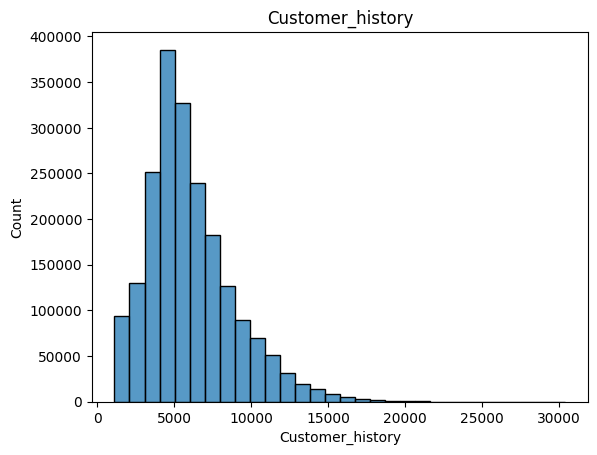

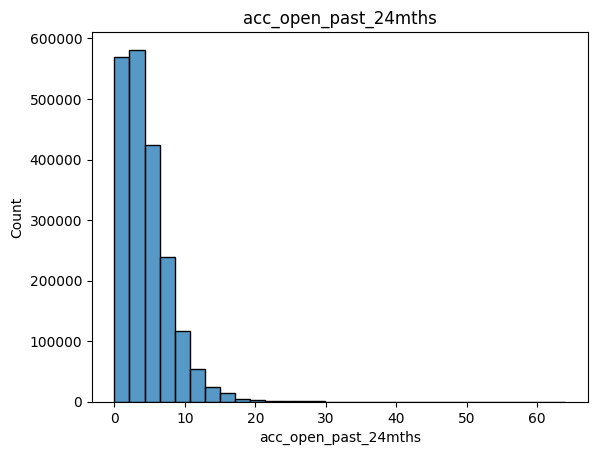

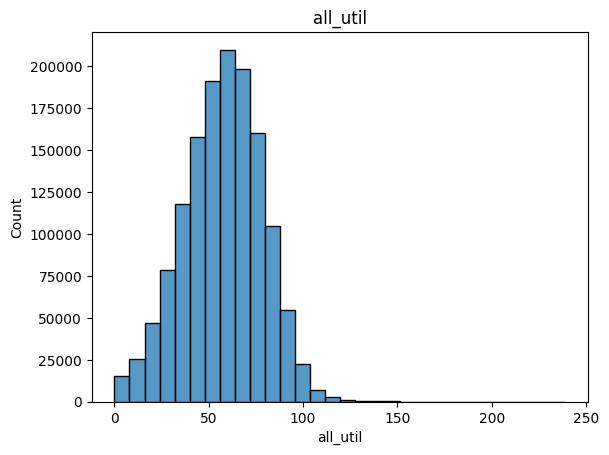

In [227]:
for col in normally_dist_variables[:3]:  # just preview first 3 to see how the numerical values are normally distributed
    sns.histplot(df[col], kde=False, bins=30)
    plt.title(col)
    plt.show()

After running this code with different setting and inspection, I conclude that the test gives inconsistent results, thus if we wish to impute then we would use the median for numerical columns

In [228]:
Cat_columns = df.select_dtypes(include=["object","category"]).columns
numerical_columns = df.select_dtypes(include="number", exclude=["category","object"]).drop('y', axis=1).columns

In [229]:
# Concatenate numeric columns explicitly(not the cross validation but just to see)
df_concated = pd.concat([df[numerical_columns].astype('float32'), pd.get_dummies(df[Cat_columns], drop_first=True, dtype='uint8').astype("category")], axis=1)

In [230]:
# Compute the absolute correlations with the numerical only values to the dependent variable
#Important to note that it is only to assess linear relationships
correlations = df_concated.corrwith(df["y"],numeric_only=True).abs().sort_values()
correlations

tot_coll_amt               0.000329
total_cu_tl                0.000595
total_bal_il               0.002915
num_bc_tl                  0.003139
delinq_amnt                0.003230
                             ...   
total_rec_prncp            0.343479
collection_recovery_fee    0.520392
recoveries                 0.528278
last_fico_range_low        0.569258
last_fico_range_high       0.636116
Length: 80, dtype: float64

In [231]:
Cat_columns = df.select_dtypes(include=["category","object"])
Cat_columns.columns

Index(['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'verification_status', 'purpose', 'addr_state', 'inq_last_6mths',
       'acc_now_delinq', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'hardship_flag',
       'debt_settlement_flag', 'issue_year', 'issue_month'],
      dtype='object')

In [232]:
#Catgorize all the columns as category for memory efficiency
df[Cat_columns.columns] =df[Cat_columns.columns].astype("category")

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029952 entries, 0 to 2029951
Data columns (total 97 columns):
 #   Column                      Dtype   
---  ------                      -----   
 0   loan_amnt                   float64 
 1   funded_amnt                 float64 
 2   funded_amnt_inv             float64 
 3   term                        category
 4   int_rate                    float64 
 5   installment                 float64 
 6   grade                       category
 7   sub_grade                   category
 8   emp_length                  category
 9   home_ownership              category
 10  annual_inc                  float64 
 11  verification_status         category
 12  purpose                     category
 13  addr_state                  category
 14  dti                         float64 
 15  delinq_2yrs                 float64 
 16  fico_range_low              float64 
 17  fico_range_high             float64 
 18  inq_last_6mths              category
 19  

In [ ]:
#df.to_csv("Post_EDA_data.csv", index=False)